# EAZY Performance Analysis

<p>The following code performs an analysis of the EAZY photometric redshift performanced with the following functions:</p>

- Comparsion with MSAEXP spectroscopic redshift
- Visualisation of select SEDs (WIP)
- Image retrieval for select targets (WIP)

#### zspec Performance Plot

In [261]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

In [262]:
RUN_NAME = 'GOODS-S'

cat_path = f'../inputs/{RUN_NAME}_photometry.cat'
cat = Table.read(cat_path, format='ascii')

cat

id,f_nircam_f090w,e_nircam_f090w,f_nircam_f115w,e_nircam_f115w,f_nircam_f150w,e_nircam_f150w,f_nircam_f182m,e_nircam_f182m,f_nircam_f200w,e_nircam_f200w,f_nircam_f210m,e_nircam_f210m,f_nircam_f277w,e_nircam_f277w,f_nircam_f335m,e_nircam_f335m,f_wfc3-uvis_f350lp,e_wfc3-uvis_f350lp,f_nircam_f356w,e_nircam_f356w,f_nircam_f410m,e_nircam_f410m,f_nircam_f430m,e_nircam_f430m,f_acs_f435w,e_acs_f435w,f_nircam_f444w,e_nircam_f444w,f_nircam_f460m,e_nircam_f460m,f_acs_f475w,e_acs_f475w,f_nircam_f480m,e_nircam_f480m,f_acs_f606w,e_acs_f606w,f_wfc3-uvis_f606w,e_wfc3-uvis_f606w,f_acs_f775w,e_acs_f775w,f_acs_f814w,e_acs_f814w,f_wfc3-uvis_f814w,e_wfc3-uvis_f814w,f_acs_f850lp,e_acs_f850lp,f_wfc3-uvis_f850lp,e_wfc3-uvis_f850lp,z_spec
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
36917,-0.06422621,0.07096801,1.746075,0.06261391,1.666677,0.06803438,1.76035,0.2092928,1.485393,0.06772508,1.72498,0.2438323,1.254657,0.04846683,1.280247,0.07479558,0.2043459,0.1644625,1.270986,0.05410079,2.538889,0.07920865,-9900.0,1000000000000.0,-0.1157944,0.06511046,1.878409,0.06895985,-9900.0,1000000000000.0,0.1219098,0.4692463,-9900.0,1000000000000.0,-0.04490506,0.04319629,-9900.0,1000000000000.0,-0.05242238,0.05290544,-0.1257573,0.1284843,-9900.0,1000000000000.0,0.1566311,0.08931852,-9900.0,1000000000000.0,7.277


In [263]:
zout_path = '../inputs/OUTPUT_BIN/photz.zout'
zout = Table.read(zout_path, format='ascii')
zout

id,z_spec,z_a,z_m1,chi_a,l68,u68,l95,u95,l99,u99,nfilt,q_z,z_peak,peak_prob,z_mc
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64
36917,7.277,7.326,7.325,207.4002,7.227,7.425,7.205,7.448,7.13,7.485,18,4.90484,7.3243,0.998,7.3109


In [264]:
diagnostic_tab = zout['id', 'z_spec', 'z_a']
diagnostic_tab['delta_z'] = np.abs((zout['z_a'] - zout['z_spec'])) / (1 + zout['z_spec'])
len_diagnostic = len(diagnostic_tab) # Account for mismatch from EAZY termination issue - FIX IF POSSIBLE

for col_name in cat.colnames:
    if col_name.startswith('f_'):
        diagnostic_tab[col_name] = cat[col_name][0:len_diagnostic]
    if col_name.startswith('e_'):
        diagnostic_tab[col_name] = cat[col_name][0:len_diagnostic]

diagnostic_tab.sort('delta_z', reverse=True)
highz_tab = diagnostic_tab[diagnostic_tab['z_spec'] > 4]

In [265]:
from pathlib import Path

# Match pivot to DAWN filter name

def pivot_wavelength(wave, throughput):
    """
    Compute pivot wavelength.
    
    Parameters
    ----------
    wave : array
        Wavelength array (same units throughout, e.g. Angstrom or micron)
    throughput : array
        Dimensionless system throughput
    
    Returns
    -------
    lambda_pivot : float
        Pivot wavelength in same units as `wave`
    """
    num = np.trapz(wave * throughput, wave)
    den = np.trapz(throughput / wave, wave)
    return np.sqrt(num / den)

# Step 1 - Identify pivot wavelengths for each filter
filter_dirs = {
    "nircam": Path("../throughputs/nircam_throughputs"),
    "niriss": Path("../throughputs/niriss_throughputs"),
    "wfc3-ir":   Path("../throughputs/wfc3-ir_throughputs"),
    "wfc3-uvis": Path("../throughputs/wfc3-uvis_throughputs"),
    "acs":    Path("../throughputs/acs_throughputs"),
}

pivot_dict = {}

import re

filter_cat = []
for col in diagnostic_tab.colnames:
    if col.startswith("f_"):
        # Extract filter name using regex (e.g., f_nircam_f150w → nircam_f150w)
        match = re.match(r"f_(.+)", col)
        if match:
            filter_cat.append(match.group(1))

n_files_found = 0
filters = []

for filt in filter_cat:
    instrument, filter = filt.split("_")  # Get instrument prefix (e.g., nircam)
    for file in filter_dirs[instrument].glob("*.txt"):
        if file.name.lower().endswith(f"{filter}.txt"):
            data = np.genfromtxt(file, names=None, dtype=float, invalid_raise=False)
            wave = data[:, 0]
            throughput = data[:, 1]  # Throughput
            if "nircam" in instrument:
                wave = wave * 10000  # Convert from micron to Angstrom
            elif "niriss" in instrument:
                wave = data[:, 0][1:] * 10000  # Wavelength (skip first row which is header)
                throughput = (data[:, 1] * data[:, 2])[1:] # Throughput - deal with unlabeled headers
            lambda_pivot = pivot_wavelength(wave, throughput)
            pivot_dict[filt] = lambda_pivot
            n_files_found += 1

            filters.append((wave, throughput))

print(n_files_found, "files found and processed.")

24 files found and processed.


#### Test 1 - SED Visualization

In [272]:
import os

def load_eazy_templates(param_path):
    base_dir = os.path.dirname(param_path)
    sed_list = [] # This will now store tuples of (wave, flux)
    ages = []
    
    with open(param_path, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip(): continue
            parts = line.split()
            filename = os.path.basename(parts[1])
            full_path = os.path.join(base_dir, filename)
            
            try:
                # Load the 2-column data
                data = np.loadtxt(full_path).T
                # Split into wavelength and flux
                wave = data[0]
                flux = data[1]
                sed_list.append((wave, flux))
            except FileNotFoundError:
                print(f"File not found: {full_path}")
                
    return sed_list

def one_tempfilt(ztry, synthesis, filters):
    NFILT = len(filters)
    
    # Initialize output
    tempfilt = np.zeros(NFILT)
    
    # Convert sed_list to a more efficient structure if not already
    # Assuming sed_list[i] is a 2D array [wavelengths, fluxes]
    
    # We still need to loop over filters and redshifts because 
    # each filter has a different wavelength grid.
    for ifilt in range(NFILT):
        w_filt, t_filt = filters[ifilt][0], filters[ifilt][1]
        
        # Pre-calculate filter normalization for this filter
        # den = integral(T * lambda * dlambda)
        norm = np.trapz(t_filt * w_filt, w_filt)
        
        # Calculate the rest-frame wavelengths the filter is "seeing"
        # lambda_rest = lambda_obs / (1 + z)
        w_rest = w_filt / (1 + ztry)

        w_sed = synthesis[0]
        f_sed = synthesis[1]
        
        # Interpolate the REST-FRAME SED onto the REST-FRAME grid 
        # that the filter covers at this redshift.
        # This is mathematically identical to redshifting the SED.
        sed_interp = np.interp(w_rest, w_sed, f_sed, left=0, right=0)
        
        # Calculate numerator: integral(F_lambda * T * lambda * dlambda)
        # We use the filter's w_filt here for dlambda
        num = np.trapz(sed_interp * t_filt * w_filt, w_filt)
        
        # Store normalized synthetic flux
        # (You can multiply by pivot_wave**2 later or here)
        tempfilt[ifilt] = num / norm
        # print(f'Filter {ifilt} done')

    return tempfilt

sed_list = load_eazy_templates('../templates/fsps_full/normalized/fsps_QSF_normalized.param')

f = open('../inputs/OUTPUT_BIN/photz.coeff','rb')
    
s = np.fromfile(file=f,dtype=np.int32, count=4)

NFILT=s[0]
NTEMP=s[1]
NZ=s[2]
NOBJ=s[3]

coeffs = np.fromfile(file=f,dtype=np.double,count=NTEMP*NOBJ).reshape((NOBJ,NTEMP))
izbest = np.fromfile(file=f,dtype=np.int32,count=NOBJ)
tnorm = np.fromfile(file=f,dtype=np.double,count=NTEMP)

f.close()

coeffs_tab = Table(coeffs, names=[f"fsps_{i}" for i in range(1, 13)])
coeffs_tab['id'] = diagnostic_tab['id']

In [267]:
def dz_plot(table, axes, plot_configs=None):
    """
    General wrapper to plot multiple diagnostics.
    
    Parameters:
    - axes: A list or array of matplotlib axis objects.
    - plot_configs: A list of functions to call. Each function must accept 
      (target, table, pivot_dict, ax) as arguments.
    """
    if plot_configs is None:
        # Default to your original two plots if none provided
        plot_configs = [plot_z_panel]

    for i, plot_func in enumerate(plot_configs):
        if i < len(axes):
            plot_func(table, axes[i])
        else:
            print(f"Warning: More plot functions provided than available axes ({len(axes)}).")

    if len(axes) > 0:
        fig = axes[0].get_figure()
        fig.suptitle("Population Diagnostics", fontsize=14)
        fig.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjusts area to not overlap title

# Systemic Analysis - Chi2 fit quality


def get_chi2_quality(table, ax):
    good_chi2s = []
    good_fit_goodness = []

    bad_chi2s = []
    bad_fit_goodness = []

    for target in table:
        id = target['id']
        chi2_arr = np.loadtxt(f'../inputs/OUTPUT/photz_{id}.pz')
        
        zphot = target['z_a']
        zspec = target['z_spec']
        dz = np.abs((zphot - zspec) / (1 + zspec))

        if dz < 0.15:
            good_chi2s.append(np.min(chi2_arr[:, 1]))
            good_fit_goodness.append(dz)

        else:
            bad_chi2s.append(np.min(chi2_arr[:, 1]))
            bad_fit_goodness.append(dz)

    ax.scatter(good_chi2s, good_fit_goodness, color='green', marker='.', label='dz < 0.15')
    ax.scatter(bad_chi2s, bad_fit_goodness, color='red', marker='.', label='dz > 0.15')
    ax.set_title('dz vs. Goodness of Fit')
    ax.set_xlabel('Best-fit $\chi^2$')
    ax.set_ylabel('dz')
    ax.legend()

def get_break_dzs(table, ax):
    good_breaks = []
    good_snr = []
    bad_breaks = []
    bad_snr = []

    for target in table:
        lya_break = 912*(target['z_spec'] + 1)

        zphot = target['z_a']
        zspec = target['z_spec']
        dz = np.abs((zphot - zspec) / (1 + zspec))

        blue_cols = []
        blue_errs = []

        for column in target.columns:
            if column.startswith('f'):
                filt_name = column.split('_', maxsplit=1)[1]
                if pivot_dict[filt_name] < lya_break:
                    blue_cols.append(target[column])
                    blue_errs.append(target['e_' + filt_name])

        snr = np.abs(np.mean(blue_cols)/np.mean(blue_errs))
        if blue_cols:
            if snr < 1:
                good_breaks.append(dz)
                good_snr.append(snr)
            else:
                bad_breaks.append(dz)
                bad_snr.append(snr)

    ax.scatter(good_snr, good_breaks, color='green', marker='.', label='Blue SNR < 2')
    ax.scatter(bad_snr, bad_breaks, color='red', marker='.', label='Blue SNR > 2')
    ax.set_title('σ_NMAD vs. Goodness of Fit')
    ax.set_xlabel('Blue filters SNR')
    ax.set_ylabel('σ_NMAD')
    ax.legend()

def get_highz_sigma(table, ax):
    dz = np.abs((table['z_a'] - table['z_spec']) / (1 + table['z_spec']))

    ax.scatter(highz_tab['z_spec'], dz, color='green', marker='.')
    ax.set_title('σ_NMAD over z')
    ax.set_ylabel('σ_NMAD')
    ax.legend()
    ax.set_xlabel('z')

In [268]:
# GENERIC DIAGNOSTIC PLOT FUNCTION

def diagnostic_plot(target, table, pivot_dict, axes, plot_configs=None):
    """
    General wrapper to plot multiple diagnostics.
    
    Parameters:
    - axes: A list or array of matplotlib axis objects.
    - plot_configs: A list of functions to call. Each function must accept 
      (target, table, pivot_dict, ax) as arguments.
    """
    zspec = table[table['id'] == target]['z_spec'][0]
    zphot = table[table['id'] == target]['z_a'][0]
    dz = np.abs((zphot - zspec) / (1 + zspec))
    if dz < 0.15:
        type = 'Good'
    else:
        type = 'Bad'
    
    if plot_configs is None:
        # Default to your original two plots if none provided
        plot_configs = [plot_z_panel]

    for i, plot_func in enumerate(plot_configs):
        if i < len(axes):
            plot_func(target, table, pivot_dict, axes[i])
        else:
            print(f"Warning: More plot functions provided than available axes ({len(axes)}).")

    if len(axes) > 0:
        target_info = table[table['id'] == target]

        fig = axes[0].get_figure()
        fig.suptitle(f"{type} Fit | Target no. {target} | MSAEXP z-spec = {target_info['z_spec'][0]}| EAZY z-phot = {target_info['z_a'][0]}", fontsize=14)
        fig.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjusts area to not overlap title

# Z-SPEC VS. Z-A PLOT
def plot_z_panel(target, table, pivot_dict, ax, zmax=10, outlier_thresh=0.15):
    colnames = [c.lower() for c in table.colnames]
    zspec_col = table.colnames[colnames.index('z_spec')] if 'z_spec' in colnames else table.colnames[colnames.index('zspec')]
    zphot_col = table.colnames[colnames.index('z_a')] if 'z_a' in colnames else table.colnames[colnames.index('z_1')]

    zspec = np.array(table[zspec_col])
    zphot = np.array(table[zphot_col])

    mask = (zspec >= 0) & (zphot >= 0)
    zspec, zphot = zspec[mask], zphot[mask]

    dz = (zphot - zspec) / (1 + zspec)
    dz = dz[np.isfinite(dz)]

    sigma_nmad = 1.48 * np.median(np.abs(dz - np.median(dz)))
    outlier_frac = np.mean(np.abs(dz) > outlier_thresh)

    ax.scatter(zspec, zphot, s=16, alpha=0.6,
               color='royalblue', edgecolor='none')

    ax.plot([0, zmax], [0, zmax], 'k--', lw=1)

    # Highlight
    if 'id' in table.colnames:
        id_array = np.array(table['id'])[mask]
        match = id_array == target

        if np.any(match):
            ax.scatter(zspec[match], zphot[match],
                       s=100, facecolor='none',
                       edgecolor='red', linewidth=2)

    ax.set_xlabel(r'$z_{\rm spec}$')
    ax.set_ylabel(r'$z_{\rm phot}$')
    ax.set_xlim(0, zmax)
    ax.set_ylim(0, zmax)
    ax.grid(alpha=0.3)

    ax.set_title('EAZY phot_z vs. MSAEXP spec_z')

    print(f"σ_NMAD = {sigma_nmad:.4f}, Outlier fraction = {outlier_frac*100:.2f}%")

# TARGET SED PLOT 
def plot_sed_panel(target, table, pivot_dict, ax):
    wavelengths, fluxes, errs = [], [], []
    target_info = table[table['id'] == target]

    for col in target_info.colnames:
        if col.startswith("f_"):
            flux = target_info[col]
            filt = col.replace("f_", "")
            if flux > 0 and filt in pivot_dict:
                wavelengths.append(pivot_dict[filt])
                fluxes.append(flux)
                errs.append(target_info[f"e_{filt}"])

    # Sorting and converting to arrays
    idx = np.argsort(wavelengths)
    w, f, e = np.squeeze(np.array(wavelengths)[idx]), np.squeeze(np.array(fluxes)[idx]), np.squeeze(np.array(errs)[idx])
    ax.errorbar(w, f, yerr=e, fmt='o', capsize=3)
    ax.plot(w, f, alpha=0.5)
    
    # Lines & Scaling
    z = target_info['z_spec']
    ax.axvline(1216 * (1 + z), ls="--", c="green", label="Ly-α")
    ax.axvline(912 * (1 + z), ls="--", c="red", label="Ly-Break")
    
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title("SED")
    ax.set_xlabel("Wavelength (Å)")
    ax.set_ylabel("Flux (μJy)")
    ax.legend(fontsize='small')

#CHI2 PLOT
def plot_chi2_panel(target, table, pivot_dict, ax):
    """
    Plots Chi-squared vs Redshift for a specific target.
    """
    
    chi2_arr = np.loadtxt(f'../inputs/OUTPUT/photz_{target}.pz')
    target_info = table[table['id'] == target]
    ax.plot(chi2_arr[:, 0], chi2_arr[:, 1], zorder=1, color='blue', lw=1.5)
    
    # Vertical lines for specific z values
    ax.axvline(target_info['z_a'], color='orange', label='phot-z', zorder=2, alpha=0.8)
    ax.axvline(target_info['z_spec'], color='green', label='Spec-z', zorder=3, alpha=0.8)
    
    # Formatting
    ax.set_xlabel('Redshift ($z$)')
    ax.set_ylabel('$\chi^2$')
    z_min, z_max = chi2_arr[:, 0][0], chi2_arr[:, 0][-1]
    ax.set_title('$\chi^2$ vs $z$')
    ax.legend(fontsize='x-small', loc='upper right')
    ax.grid(True, alpha=0.3)

# COMP TO BEST-FIT TEMPLATE COMBINATION
def plot_best_fit(target, table, pivot_dict, ax):
    """
    Plots best-fit combination of templates for a particular target.
    """
    wavelengths, fluxes, errs = [], [], []
    target_info = table[table['id'] == target]

    for col in target_info.colnames:
        if col.startswith("f_"):
            flux = target_info[col]
            filt = col.replace("f_", "")
            if flux > 0 and filt in pivot_dict:
                wavelengths.append(pivot_dict[filt])
                fluxes.append(flux)
                errs.append(target_info[f"e_{filt}"])

    # Sorting and converting to arrays
    idx = np.argsort(wavelengths)
    w, f, e = np.squeeze(np.array(wavelengths)[idx]), np.squeeze(np.array(fluxes)[idx]), np.squeeze(np.array(errs)[idx])

    target_matrix = coeffs_tab[coeffs_tab['id'] == target]
    flux_synthesis = np.zeros_like(sed_list[0])
    proportions = []

    for i in range(len(target_matrix.colnames) - 1):
        flux_synthesis += target_matrix[target_matrix.colnames[i]][0] * sed_list[i][1]
        proportions.append(target_matrix[target_matrix.colnames[i]][0])

    # Report significant contributing templates
    proportions = np.array(proportions)
    template_names = np.array(target_matrix.colnames)
    template_names = template_names[template_names != 'id']
    sort_order = np.argsort(proportions)[::-1]

    print(proportions)
    print('Largest Contributors:')
    for i in range(3):
        print(f"Template {template_names[sort_order][i]} had coefficient {proportions[sort_order][i]}")

    synthesis = np.array([sed_list[0][0], flux_synthesis[0]])
    z_a = target_info[target_info['id'] == target]['z_a'][0]

    tempfilt = one_tempfilt(z_a, synthesis, filters)

    ax.scatter(pivot_dict.values(), tempfilt, color='red', zorder=2, label='Best template')    
    ax.errorbar(w, f, yerr=e, fmt='o', capsize=3, label='Real')

    wl_redshifted = synthesis[0] * (z_a + 1)

    lowlimit = wl_redshifted > np.min(np.array(list(pivot_dict.values()))) - 100
    highlimit = wl_redshifted < np.max(np.array(list(pivot_dict.values()))) + 100
    allowed_w = lowlimit & highlimit
    ax.plot(wl_redshifted[allowed_w], synthesis[1][allowed_w], zorder=1)
    
    # Lines & Scaling
    z = target_info['z_spec']
    
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(fontsize='small')

    ax.set_xlabel('Redshifted wavelength (Å)')
    ax.set_ylabel('Flux (µJy)')
    ax.set_title(f'Best-Fit Template for Target No. {target}')

In [269]:
highz_tab = diagnostic_tab[diagnostic_tab['z_spec'] > 4]
target1 = highz_tab[10]['id']
target2 = highz_tab[-10]['id']

IndexError: index 10 out of range for table with length 1

σ_NMAD = 0.1565, Outlier fraction = 46.61%
σ_NMAD = 0.1565, Outlier fraction = 46.61%


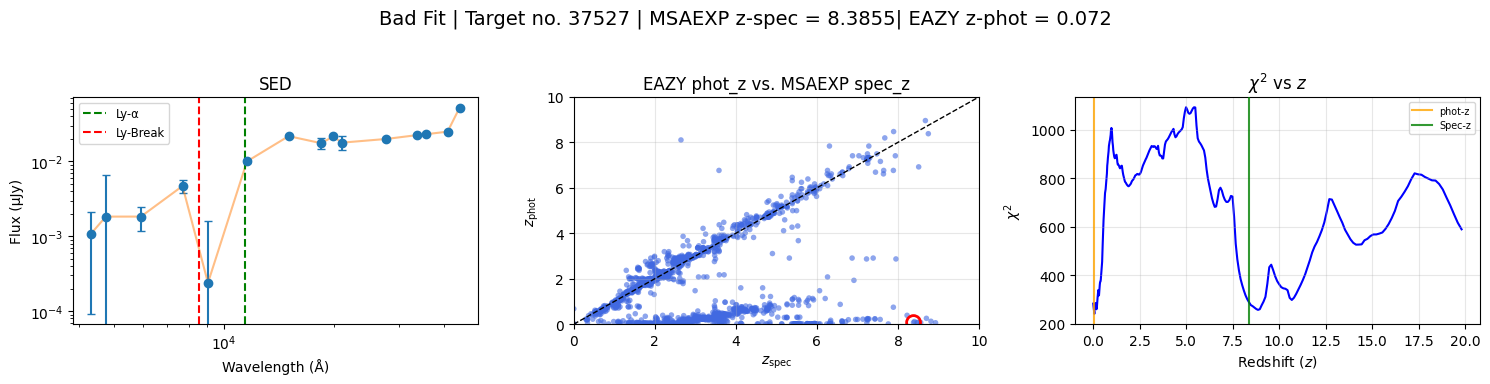

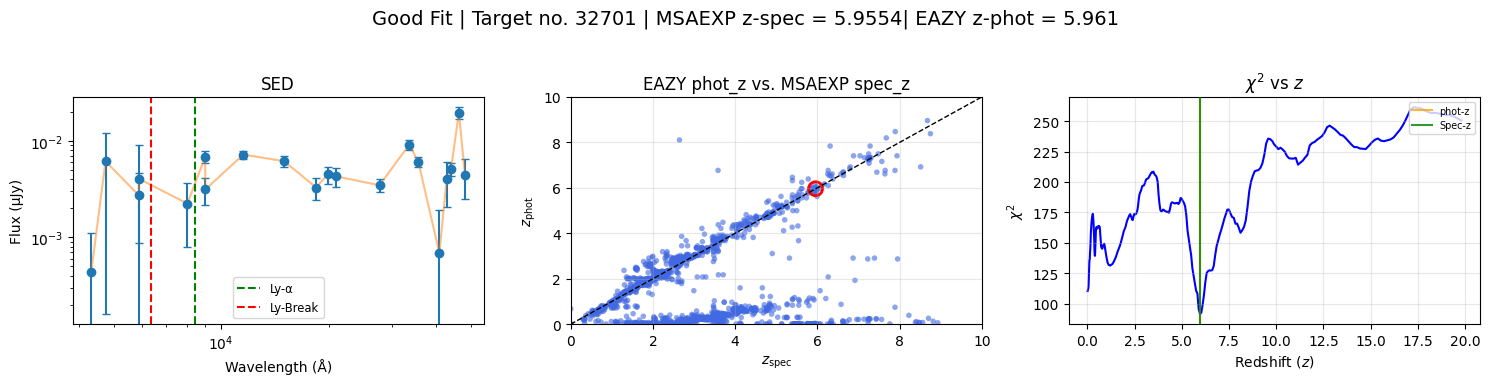

In [199]:
# Define which plots you want to run
my_diagnostics = [plot_sed_panel, plot_z_panel, plot_chi2_panel]

# 1. Force axes to always be an array with squeeze=False
fig1, axes1 = plt.subplots(1, len(my_diagnostics), 
                         figsize=(5 * len(my_diagnostics), 4), 
                         squeeze=False)

# 2. Flatten the axes array to 1D so the wrapper can iterate easily
# (Since squeeze=False returns a 2D array [[ax1, ax2]], .flatten() gives [ax1, ax2])
axes1_flat = axes1.flatten()

# 3. Call the wrapper with the flattened axes
diagnostic_plot(
    target=target1, 
    table=diagnostic_tab, 
    pivot_dict=pivot_dict, 
    axes=axes1_flat, 
    plot_configs=my_diagnostics
)

# Bad target
fig2, axes2 = plt.subplots(1, len(my_diagnostics), 
                         figsize=(5 * len(my_diagnostics), 4), 
                         squeeze=False)
axes2_flat = axes2.flatten()
diagnostic_plot(
    target=target2, 
    table=diagnostic_tab, 
    pivot_dict=pivot_dict, 
    axes=axes2_flat, 
    plot_configs=my_diagnostics
)

/var/folders/g6/3sy022nj17q9pf3kxl2bqh040000gn/T/ipykernel_78028/4258740968.py:103: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


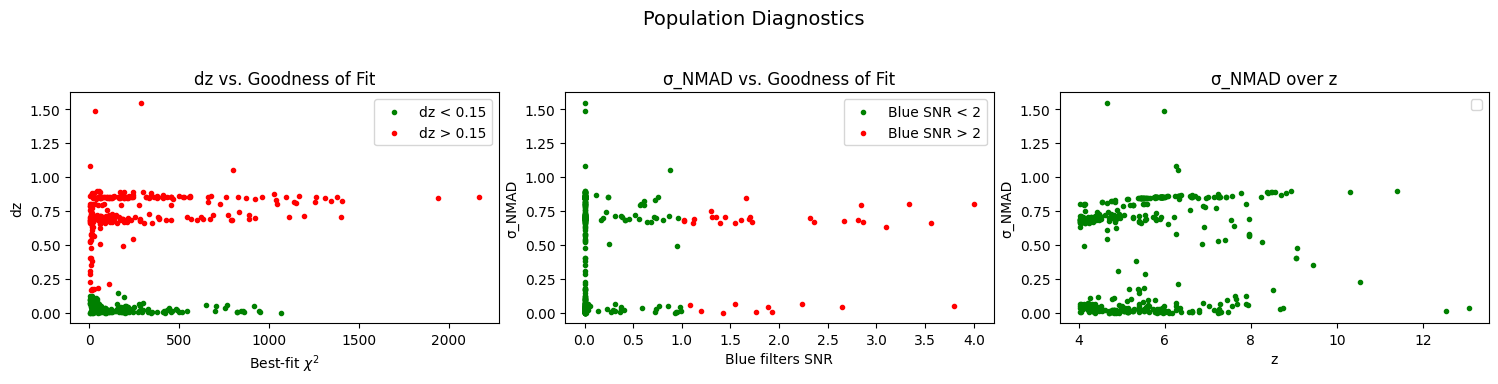

In [182]:
group_diagnostics = [get_chi2_quality, get_break_dzs, get_highz_sigma]

fig, axes = plt.subplots(1, len(my_diagnostics), 
                         figsize=(5 * len(my_diagnostics), 4), 
                         squeeze=False)

axes_flat = axes.flatten()

dz_plot(highz_tab, axes_flat, group_diagnostics)

In [270]:
target3 = highz_tab[0]

σ_NMAD = 0.0000, Outlier fraction = 0.00%
[6.43473296e-06 9.62261424e-07 1.76764185e-06 6.91494175e-06
 1.59303786e-05 1.87353688e-04 1.56419581e+00 1.95593595e-03
 6.64145869e-05 1.86458860e-05 1.36518588e-05 7.83095457e-05]
Largest Contributors:
Template fsps_7 had coefficient 1.5641958054500147
Template fsps_8 had coefficient 0.0019559359485319863
Template fsps_6 had coefficient 0.00018735368780958998


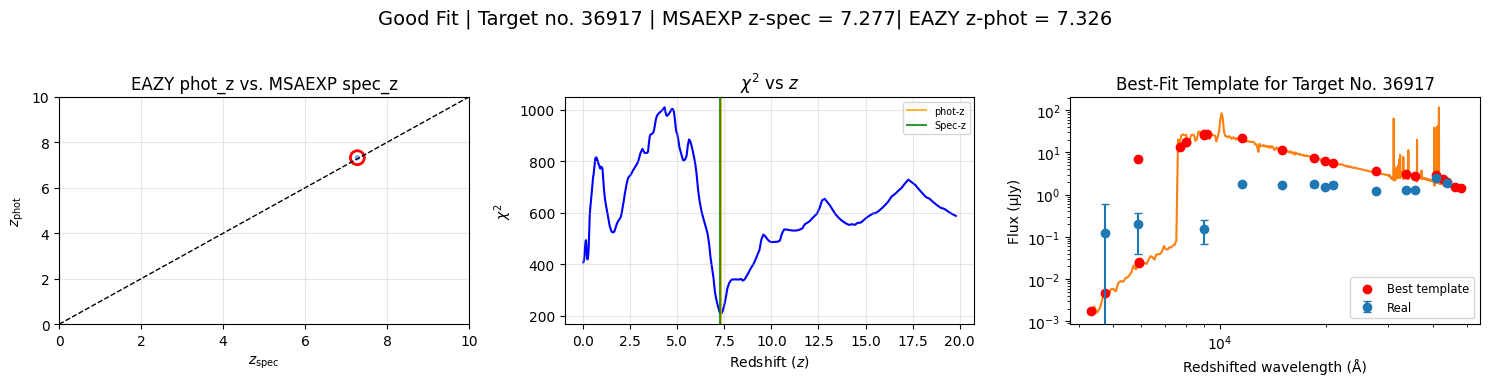

In [273]:
# Define which plots you want to run
my_diagnostics = [plot_z_panel, plot_chi2_panel, plot_best_fit]

# 1. Force axes to always be an array with squeeze=False
fig, axes = plt.subplots(1, len(my_diagnostics), 
                         figsize=(5 * len(my_diagnostics), 4), 
                         squeeze=False)

# 2. Flatten the axes array to 1D so the wrapper can iterate easily
# (Since squeeze=False returns a 2D array [[ax1, ax2]], .flatten() gives [ax1, ax2])
axes_flat = axes.flatten()

# 3. Call the wrapper with the flattened axes
diagnostic_plot(
    target=target3['id'], 
    table=diagnostic_tab, 
    pivot_dict=pivot_dict, 
    axes=axes_flat, 
    plot_configs=my_diagnostics
)

1.7332472837588737


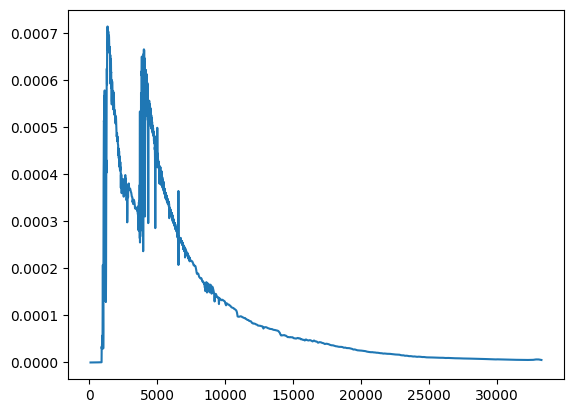

In [260]:
nfilt = 0

template_flux = sed_list[nfilt][1][0:5000]

plt.figure()
plt.plot(sed_list[nfilt][0][0:5000], sed_list[nfilt][1][0:5000])

print(np.sum(template_flux))

# Test 2 - EAZY Recreation

In [ ]:
import os

def load_eazy_templates(param_path):
    base_dir = os.path.dirname(param_path)
    sed_list = [] # This will now store tuples of (wave, flux)
    ages = []
    
    with open(param_path, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip(): continue
            parts = line.split()
            filename = os.path.basename(parts[1])
            full_path = os.path.join(base_dir, filename)
            
            try:
                # Load the 2-column data
                data = np.loadtxt(full_path).T
                # Split into wavelength and flux
                wave = data[0]
                flux = data[1]
                sed_list.append((wave, flux))
            except FileNotFoundError:
                print(f"File not found: {full_path}")
                
    return sed_list

In [55]:
# Load all the templates from the catalog

sed_list = load_eazy_templates('../templates/fsps_full/fsps_QSF_12_v3.param')

In [56]:
# Get filter behavior
filters = []

for filt in filter_cat:

    instrument, filter = filt.split("_")  # Get instrument prefix (e.g., nircam)
    for file in filter_dirs[instrument].glob("*.txt"):
        if file.name.lower().endswith(f"{filter}.txt"):
            data = np.genfromtxt(file, names=None, dtype=float, invalid_raise=False)
            wave = data[:, 0]  # Wavelength
            throughput = data[:, 1]  # Throughput
            if "nircam" in instrument:
                wave = wave * 10000  # Convert from micron to Angstrom
            elif "niriss" in instrument:
                wave = data[:, 0][1:]  # Wavelength (skip first row which is header)
                throughput = (data[:, 1] * data[:, 2])[1:] # Throughput - deal with unlabeled headers

    filters.append((wave, throughput))

In [57]:
def build_tempfilt(ztry, sed_list, filters):
    NZ = len(ztry)
    NTEMP = len(sed_list)
    NFILT = len(filters)
    
    # Initialize output
    tempfilt = np.zeros((NZ, NTEMP, NFILT))
    
    # Convert sed_list to a more efficient structure if not already
    # Assuming sed_list[i] is a 2D array [wavelengths, fluxes]
    
    # We still need to loop over filters and redshifts because 
    # each filter has a different wavelength grid.
    for ifilt in range(NFILT):
        w_filt, t_filt = filters[ifilt][0], filters[ifilt][1]
        
        # Pre-calculate filter normalization for this filter
        # den = integral(T * lambda * dlambda)
        norm = np.trapz(t_filt * w_filt, w_filt)
        
        for iz, z in enumerate(ztry):
            # Calculate the rest-frame wavelengths the filter is "seeing"
            # lambda_rest = lambda_obs / (1 + z)
            w_rest = w_filt / (1 + z)
            
            for itemp in range(NTEMP):
                w_sed = sed_list[itemp][0]
                f_sed = sed_list[itemp][1]
                
                # Interpolate the REST-FRAME SED onto the REST-FRAME grid 
                # that the filter covers at this redshift.
                # This is mathematically identical to redshifting the SED.
                sed_interp = np.interp(w_rest, w_sed, f_sed, left=0, right=0)
                
                # Calculate numerator: integral(F_lambda * T * lambda * dlambda)
                # We use the filter's w_filt here for dlambda
                num = np.trapz(sed_interp * t_filt * w_filt, w_filt)
                
                # Store normalized synthetic flux
                # (You can multiply by pivot_wave**2 later or here)
                tempfilt[iz, itemp, ifilt] = num / norm

        print(f'Filter {ifilt} done')

    return tempfilt

In [58]:
ztry = np.arange(0, 20, 0.01)

tempfilt = build_tempfilt(ztry, sed_list, filters)

Filter 0 done
Filter 1 done
Filter 2 done
Filter 3 done
Filter 4 done
Filter 5 done
Filter 6 done
Filter 7 done
Filter 8 done
Filter 9 done
Filter 10 done
Filter 11 done
Filter 12 done
Filter 13 done
Filter 14 done
Filter 15 done
Filter 16 done
Filter 17 done
Filter 18 done
Filter 19 done
Filter 20 done
Filter 21 done
Filter 22 done
Filter 23 done


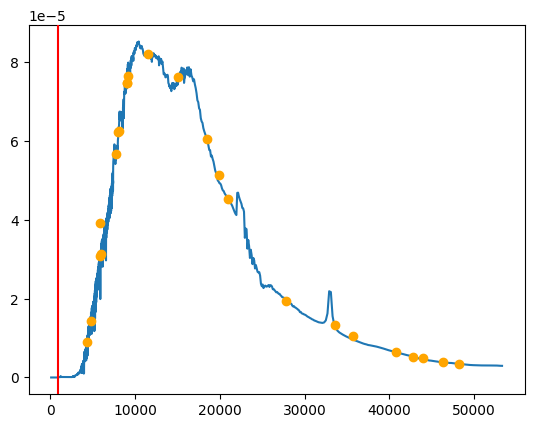

In [59]:
ix = 5

plt.figure()
plt.plot(sed_list[ix][0][0:5100], sed_list[ix][1][0:5100], zorder=1)
plt.scatter(pivot_dict.values(), tempfilt[0][ix], color='orange', zorder=2)
plt.axvline(912, color='red', zorder=3)

# for i in range(24):
    # print(f"filter {list(pivot_dict.keys())[i]} -> temp_flux {tempfilt[0][ix][i]}")

In [17]:
from scipy.interpolate import interp1d

def load_template_error(file_path):
            """
            Reads the TEF file and returns an interpolation function.
            """
            # Load the wavelength and error columns
            # Column 0: Wavelength (A), Column 1: Error amplitude
            tef_data = np.loadtxt(file_path)
            te_x = tef_data[:, 0]
            te_y = tef_data[:, 1]
            
            # Create an interpolation function. 
            # Use fill_value to handle wavelengths outside the file's range.
            return interp1d(te_x, te_y, kind='linear', bounds_error=False, fill_value=(te_y[0], te_y[-1]))

In [18]:
load_template_error('../templates/template_error_cosmos2020.txt')

In [1]:
import numpy as np

def nonneg_fact(amatrix, bvector, coeffs, toler=1e-4, max_iter=100000):
    """
    Replicates the Sha, Saul, & Lee multiplicative update algorithm.
    """
    itcount = 0
    tol = 100.0
    
    # Ensure coeffs is a float array for in-place updates
    coeffs = coeffs.astype(float)
    
    while tol > toler and itcount < max_iter:
        vold = coeffs.copy()
        
        # Matrix-vector product: av = A * x
        av = np.dot(amatrix, coeffs)
        
        # Multiplicative update: coeffs = coeffs * (-b / av)
        # Note: In the C code, bvector is pre-multiplied by -1
        coeffs *= (-bvector / av)
        
        # Calculate tolerance (relative change)
        tolnum = np.sum(np.abs(coeffs - vold))
        toldenom = np.sum(vold)
        
        if toldenom == 0:
            break
            
        tol = tolnum / toldenom
        itcount += 1
        
    return coeffs, itcount

def get_best_fit_at_z(obs_flux, obs_err, temp_fluxes, sys_err=0.03):
    """
    Calculates the best-fit coefficients for a set of templates at a SINGLE redshift.
    
    Parameters:
    obs_flux: Array of observed fluxes (N_filters)
    obs_err: Array of flux errors (N_filters)
    temp_fluxes: 2D Array of template fluxes at current Z (N_templates, N_filters)
    """
    n_temp, n_filt = temp_fluxes.shape
    
    # 1. Calculate Variance (sigma^2)
    # EAZY formula: sig2 = (sys_err * flux)^2 + obs_err^2
    sig2 = (sys_err * obs_flux)**2 + obs_err**2
    
    # 2. Build amatrix (A) and bvector (b)
    # A_ij = sum_k (Temp_i,k * Temp_j,k / sig2_k)
    # b_i = -sum_k (Flux_k * Temp_i,k / sig2_k)
    
    amatrix = np.zeros((n_temp, n_temp))
    bvector = np.zeros(n_temp)
    
    # Efficient matrix construction using NumPy broadcasting
    inv_sig2 = 1.0 / sig2
    for i in range(n_temp):
        for j in range(n_temp):
            amatrix[i, j] = np.sum(temp_fluxes[i] * temp_fluxes[j] * inv_sig2)
        
        bvector[i] = -np.sum(obs_flux * temp_fluxes[i] * inv_sig2)
        
    # 3. Initial Guess for coefficients
    # EAZY logic: if b < 0 set to 1, else 0
    coeffs = np.where(bvector < 0, 1.0, 0.0)
    
    # 4. Solve
    best_coeffs, iterations = nonneg_fact(amatrix, bvector, coeffs)
    
    # 5. Calculate Chi-Squared
    model_flux = np.dot(best_coeffs, temp_fluxes)
    chi2 = np.sum(((model_flux - obs_flux)**2) / sig2)
    
    return chi2, best_coeffs

In [43]:
target = highz_tab[-10]
fnu = np.array([target[column] for column in target.columns if column.startswith("f_")])
efnu = np.array([target[f"e_{column.split('_')[1]}_{column.split('_')[2]}"] for column in target.columns if column.startswith("f_")])

chi2, best_coeffs = get_best_fit_at_z(fnu, efnu, tempfilt[0])

In [44]:
chi2_arr = []
coeff_matrix = []

for i in range(tempfilt.shape[0]):
    chi2, best_coeffs = get_best_fit_at_z(fnu, efnu, tempfilt[i])
    chi2_arr.append(chi2)
    coeff_matrix.append(best_coeffs)

    if i % 100 == 0:
        print(i)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900


Target 47853: z_spec = 6.573, z_phot = 6.613, delta_z = 0.005


InconsistentTableError: 
ERROR: Unable to guess table format with the guesses listed below:
reader_cls:Ecsv fast_reader: {'enable': True} fill_values: [('', '0')] strict_names: True
reader_cls:FixedWidthTwoLine fast_reader: {'enable': True} fill_values: [('', '0')] strict_names: True
reader_cls:RST fast_reader: {'enable': True} fill_values: [('', '0')] strict_names: True
reader_cls:FastBasic fast_reader: {'enable': True} fill_values: [('', '0')] strict_names: True
reader_cls:Basic fast_reader: {'enable': True} fill_values: [('', '0')] strict_names: True
reader_cls:FastRdb fast_reader: {'enable': True} fill_values: [('', '0')] strict_names: True
reader_cls:Rdb fast_reader: {'enable': True} fill_values: [('', '0')] strict_names: True
reader_cls:FastTab fast_reader: {'enable': True} fill_values: [('', '0')] strict_names: True
reader_cls:Tab fast_reader: {'enable': True} fill_values: [('', '0')] strict_names: True
reader_cls:Cds fast_reader: {'enable': True} fill_values: [('', '0')] strict

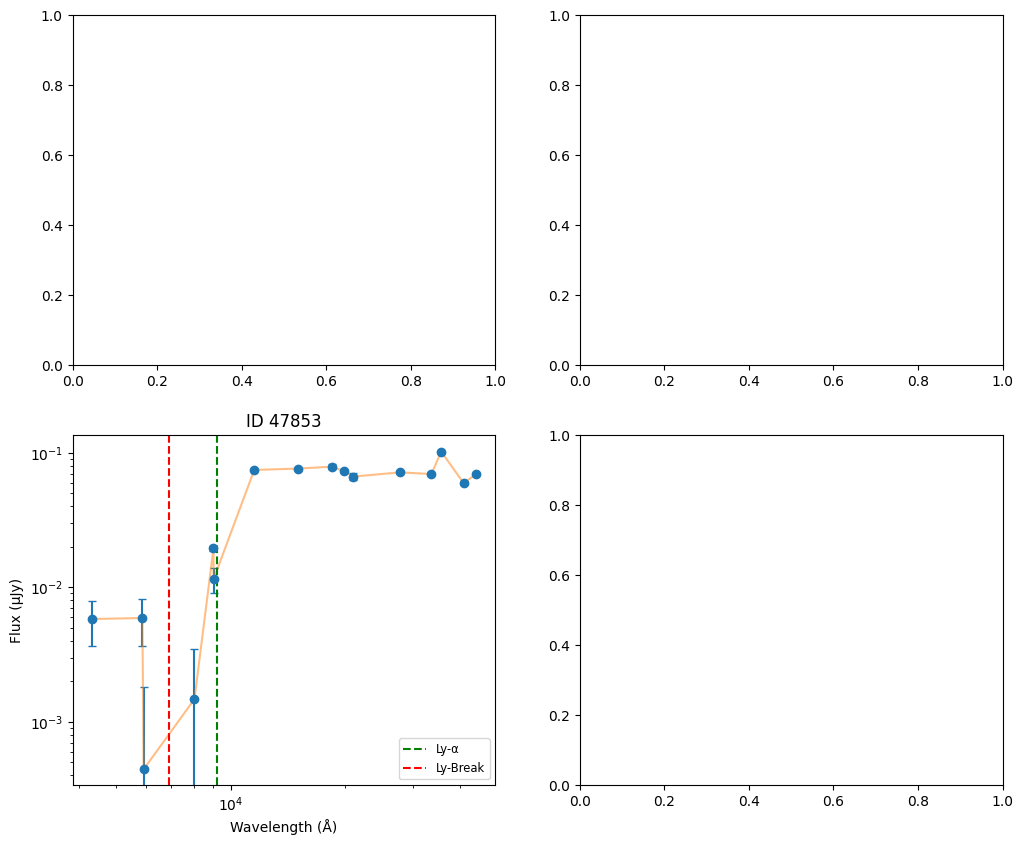

In [70]:
target2 = highz_tab[-10]
print(f"Target {target2['id']}: z_spec = {target2['z_spec']:.3f}, z_phot = {target2['z_a']:.3f}, delta_z = {target2['delta_z']:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(12,10))

diagnostic_plot(target2, diagnostic_tab, pivot_dict, axes[1])

plt.tight_layout()
plt.show()

# Quality cutoff at highz index 220

Chi^2 plot of Target No. 47853


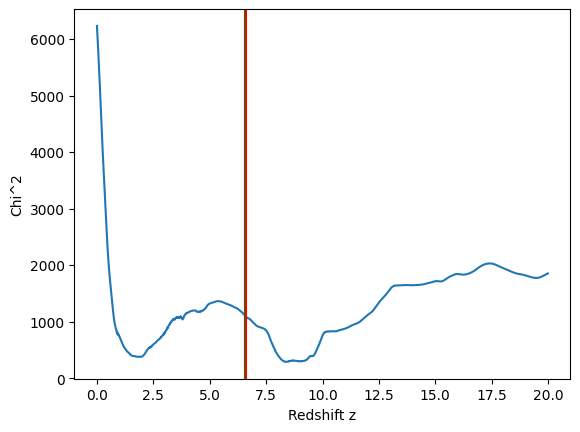

In [49]:
id = target['id']

print(f'Chi^2 plot of Target No. {id}')
plt.figure()
plt.plot(ztry, chi2_arr)
plt.xlabel('Redshift z')
plt.ylabel('Chi^2')
plt.axvline(target['z_spec'], color='green')
plt.axvline(target['z_a'], color='red')

In [ ]:
target = highz_tab[-10]
fnu = np.array([target[column] for column in target.columns if column.startswith("f_")])
efnu = np.array([target[f"e_{column.split('_')[1]}_{column.split('_')[2]}"] for column in target.columns if column.startswith("f_")])

chi2_arr = []
coeff_matrix = []

for i in range(tempfilt.shape[0]):
    chi2, best_coeffs = get_best_fit_at_z(fnu, efnu, tempfilt[i])
    chi2_arr.append(chi2)
    coeff_matrix.append(best_coeffs)

    if i % 100 == 0:
        print(i)

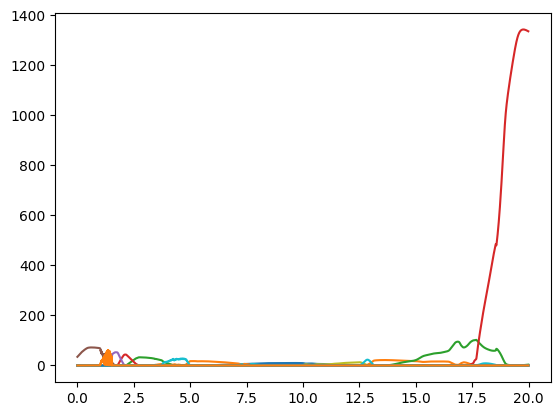

In [ ]:
target2 = highz_tab[-10]
print(f"Target {target2['id']}: z_spec = {target2['z_spec']:.3f}, z_phot = {target2['z_a']:.3f}, delta_z = {target2['delta_z']:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(12,10))

diagnostic_plot(target2, diagnostic_tab, pivot_dict, axes[1])

plt.tight_layout()
plt.show()

# Quality cutoff at highz index 220

## Visualization

Target 16180: z_spec = 8.562, z_phot = 0.072, delta_z = 0.888
Target 47853: z_spec = 6.573, z_phot = 6.613, delta_z = 0.005
σ_NMAD = 0.1565, Outlier fraction = 46.61%
σ_NMAD = 0.1565, Outlier fraction = 46.61%


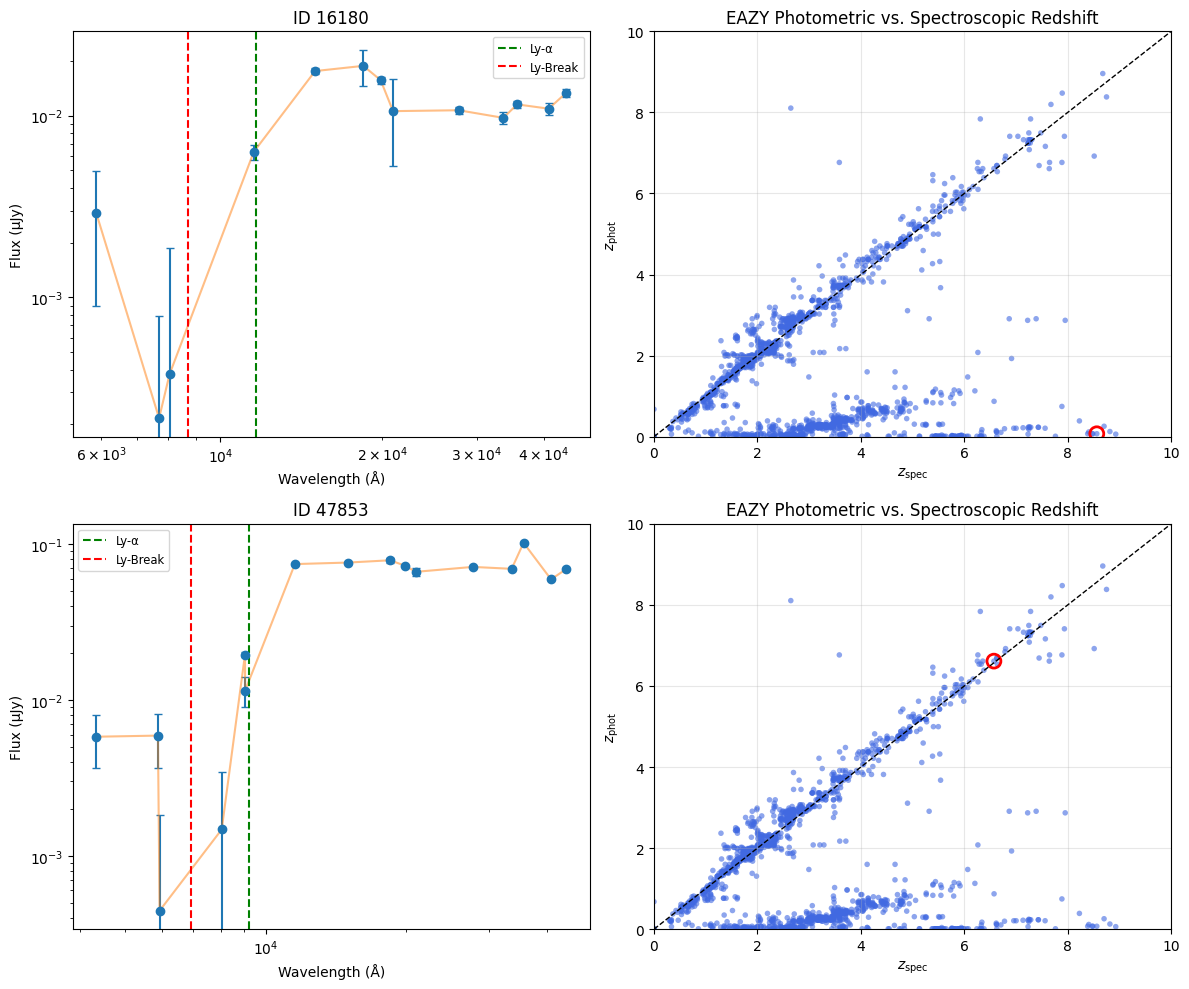

In [22]:
target1 = highz_tab[5]
target2 = highz_tab[-10]
print(f"Target {target1['id']}: z_spec = {target1['z_spec']:.3f}, z_phot = {target1['z_a']:.3f}, delta_z = {target1['delta_z']:.3f}")
print(f"Target {target2['id']}: z_spec = {target2['z_spec']:.3f}, z_phot = {target2['z_a']:.3f}, delta_z = {target2['delta_z']:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(12,10))

diagnostic_plot(target1, diagnostic_tab, pivot_dict, axes[0])
diagnostic_plot(target2, diagnostic_tab, pivot_dict, axes[1])

plt.tight_layout()
plt.show()

# Quality cutoff at highz index 220

In [ ]:
import matplotlib.pyplot as plt

# Define which plots you want to run
my_diagnostics = [plot_sed_panel, plot_z_panel, plot_chi2_panel]

# Create subplots dynamically
fig, axes = plt.subplots(1, len(my_diagnostics), figsize=(5 * len(my_diagnostics), 4))

# Run the wrapper
diagnostic_plot(target1, diagnostic_tab, pivot_dict, axes, plot_configs=my_diagnostics)

plt.tight_layout()
plt.show()